# Versuch 233 "Fourieroptik"

In [1]:
#imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import scipy.optimize
import sympy as sp
import pylab as py
import decimal as dc


from numpy import random
from scipy.optimize import curve_fit
from scipy.special import factorial
from scipy.stats import poisson
from scipy.integrate import quad
from scipy import signal
from IPython.display import display, Math, Latex
from sympy import separatevars
from decimal import Decimal, ROUND_HALF_UP

#Brennweite von L1 in m
f_l1 = 0.08

#Wellenlänge des Lasers in m
lam = 532/10**9

# Funktionen

In [2]:
#     Autor: Daniel Härterich #verändert
"""
    Funktion formatiert Arrays an Daten in Latex-Tabellenformat
    data: Daten als 2D-Array[[x1,x2,..],[a1,a2,...],...]
    header: Spaltenüberschriften als 1D-Array mit gleicher Zeilenlänge wie Daten-Array
    caption: optionaler string als Titel der Tabelle

    Hinweis: Latex Namen mit doppeltem \\ 
"""

def latex_tabelle(data, header=None, caption=''): 
    format = '|c'
    for a in range(np.size(header)-1):
        #print(format)
        format += '|c'
    format +="|"
    tex = ('\\begin{table}\\label{}\n\t\\centering\n\t\\caption{'
           +caption+ '}\n\t\\begin{tabular}{' + format +'}\n \\hline\t\t')
    if len(header)>0:
        head = str(header[0])
        for i in range(1, np.size(header)):
            head += ' & ' + str(header[i])
        head += ' \\\\ ' + '\\hline' 
        tex += head
    
    if len(data)>0:
        for j in range(np.size(data[0,:])):
            zeile = '\n\t\t' + str(data[0][j])
            for i in range(1, np.size(data[:,j])):
                zeile += ' & ' + str(data[i][j])
            zeile += ' \\\\'
            tex += zeile
    tex += '\n\\hline\n\t\\end{tabular}\n\\end{table}'
    print(tex)

"""
Wandelt einen einzelnen Wert in einen Array der Länge eines anderen Arrays um.
Oder expandiert einen Arrax, in dem er jede Stelle mehrfach nimmt
a: Input, zahl oder 1D Array
reference: Array, an den die Länge angepasst werden soll
repeat: Anzahl wie oft jeder Wert des Arrays im neuen Array auftauchen soll 

Hinweis: repeat*len(a) sollte der Länge von allen anderen Arrays der Tabelle später entsprechen, sonst kommt es zu Problemen
"""
def array_anpassung(a, reference=None, repeat=1):
    x = np.array([])
    if np.ndim(a)!= 0:
        for j in range(np.size(a)):
            for k in range(repeat):
                x = np.append(x, a[j])
    else:
        for i in range(np.size(reference)):
            x = np.append(x, a)
    return x

""" 
Generiert einen Array der Länge eines Referenzarrays mit Zahlen 1,2,...
"""
def nummer_array_generator(reference):
    r = np.array([])
    for i in range(np.size(reference)):
        r = np.append(r, (i+1))
    return r

In [3]:
#     Autor: Daniel Härterich
"""
Rundet Daten oder ihren Fehler auf signifikante Stellen. Entweder nur Fehler angeben um Fehler zu runden oder Fehler und Daten angeben um Daten auf signifikante Stellen passend zum Fehler gerundet zu erhalten.

daten: 1D array mit gleicher Länge wie Fehler, Zahl, oder nichts
fehler: 1D array, oder Zahl

Problem, das nicht gefixt ist/ wird: Signifikante 0-Stellen am Ende werden nicht richtig angezeigt. Hier manuell nachbessern!
"""
def significant(fehler, daten=np.array([])):
    x=0
    x_a=np.array([])
    #print("1",fehler)
    if np.isscalar(fehler):
        x = signifikante_Stellen(fehler)
    else:
        for i in range(np.size(fehler)):
            #print("2",i,fehler)
            x_a = np.append(x_a, signifikante_Stellen(fehler[i]))
    if np.isscalar(daten):
        return korrekt_Runden(daten, x)
    elif np.size(daten)!=0:
        daten_round = np.zeros(len(daten))
        if np.isscalar(fehler):
            for j in range(np.size(daten)):
                daten_round[j] = korrekt_Runden(daten[j], x)
        else:
            for k in range(np.size(daten)):
                daten_round[k] = korrekt_Runden(daten[k], x_a[k])
        return daten_round
    else:
        if np.isscalar(fehler):
            return korrekt_Runden(fehler, x)
        else:
            fehler_round = np.zeros(len(fehler))
            for l in range(np.size(fehler)):
                fehler_round[l] = korrekt_Runden(fehler[l], x_a[l])
            return fehler_round
        
# Minifunktion um die Signifikanten Stellen herauszufinden
def signifikante_Stellen(fehler):
    if np.ndim(fehler) == 0:
        x = int(np.floor(np.log10(fehler)))
        sigf = Decimal(fehler/10**(x))
        if(sigf<3):
            x-=1
        return x
    else:
        x = np.floor(np.log10(fehler))
        sigf = fehler/10**(x)
        for i in range(np.size(x)):
            if(sigf[i]<3):
                x[i]-=1
        return x

# Minifunktion um Zahl an bestimmter Stelle abzuschneiden und korrekt zu runden
def korrekt_Runden(Zahl, Stelle):
    ten = Decimal(10)
    ret = Decimal(Zahl)/ten**(Decimal(Stelle))+Decimal('0.01')
    ret = ret.quantize(dc.Decimal('1'),dc.ROUND_HALF_UP)
    ret=ret*ten**(Decimal(Stelle))
    return ret

In [4]:
"""
    Bringt einen Wert mit Fehler in das Format für eine Latex Tabelle

    Value: Datenwert als Zahl oder 1D array
    error: Fehler als Zahl oder 1D array, bei konstantem Fehler über einen 1D Array für Value reicht es eine Zahl anzugeben.
    significant: Rundet auf signifikante Stellen nach Daniels Funktion
"""
def to_latex(value,error,sig = True):
    if sig:
        value = significant(error,daten = value)
        error = significant(error)
    if(np.isscalar(value)):
        latex = str("$" + str(value) +  chr(92) +"pm " + str(error)+"$")
    else:
        if(np.isscalar(error)):
            error = np.full(len(value),error)
        latex = np.empty(len(value),dtype = object)
        for i in range(len(value)):
            latex[i] = str("$" + str(value[i]) +  chr(92) +"pm " + str(error[i])+"$")
    return latex

In [5]:
#Funktion für Sigma-Abweichung
def Abweichung(x, fx, y, fy):
    return abs(x-y)/ np.sqrt(fx**2 +fy**2)

#Funktion für prozentuale Abweichung
def Abweichung_proz(x, y):
    return 100*abs(x-y)/ (x)

In [6]:

"""
errf gibt zu einer Funktion und deren fehlerbehafteten Parametern den Fehler nach Gaußscher Fehlerfortpflanzung aus
function: eine sympy Funktion
param: alle fehlerbehafteten Parameter in einem Array
"""
def errf(function, param):
    error = 0
    parameters = []
    for par in param:
        d = sp.symbols('dstringdenniemandbenutzt' + par.name)
        partial = sp.diff(function, par) * d    
        error = error + partial**2
        parameters.append((par,d))
    error_abs=sp.simplify(sp.sqrt(error),rational = True)             
    error_rel=sp.simplify(sp.sqrt(error/function**2),rational = True)
    return(error_abs, error_rel, parameters)

In [7]:
"""
Berechnet Wert und Fehler für Daten
f: eine sympy Funktion
err: eine sympy Funktion, die den Fehler berechnet
data: Als array von Tupeln der Form [(a,da),(b,db),...] oder als array/liste [a,da,b,db,...)] (Reihenfolge muss die sein, in der die Argumente in
    der Funktion genommen werden)
"""
def evaluate_with_error(f, err, values):
    if (np.ndim(values) != 1):                    #Falls der Input in mehrere Tupel aufgeteilt ist, werden diese zu einem Array zusammengefügt 
        values = np.concatenate(values)
    #print(values)
    result = f(*values[::2])
    uncertainty = err(*values)
    return result, uncertainty
    

In [8]:
"""
Darstellung einer Funktion in Latex
f: eine sympy Funktion
"""
def function_to_latex(f):
    print("Funktion:")
    display(Math(sp.latex(f,long_frac_ratio=2).replace('dstringdenniemandbenutzt',r'\Delta ')))
    print("Latex Code:")
    print(sp.latex(f,long_frac_ratio=2).replace('dstringdenniemandbenutzt',r'\Delta '))

In [9]:
#Hier soll eine Funktion entstehen, die eine Funktion auf einen Wert anwendet und gleichzeitig den Fehler ausrechnet
#Erstmal für Eingabe der Daten in Form von 2d Arrays

"""
Gibt pro Zeile den Wert und den absoluten Fehler der Daten bzgl. der gegebenen Funktion aus
Zusätzlich printet sie den Latex Code für die Formel, sowie die Fehlerformeln (Beim relativen Fehler unbedingt an die Multiplikation vom Ergebnis denken!)

Argumente:
function: sympy Funktion, in die die Messwerte eingesetzt werden sollen

params: Alle Parameter dieser Funktion als Array von Sympy-Zeichen

data: 2D-Array mit den Messdaten, sodass die Zeilen die Form haben: [Parameter 1, Fehler Parameter 1, Parameter 2,...]
Die Funktion wird zeilenweise angewandt. Wird kein Fehler für einen Parameter angenommen, kann diese Spalte entweder mit dem Wert 0 
an die Funktion gegeben werden oder ganz weggelassen werden. Dann muss allerdings der betreffende Parameter bei params_without_error angegeben werden.

params_without_error: Alle Parameter zu denen kein Fehler explizit in den Daten angegeben ist. Dieser wird auf 0 gesetzt und kommt dann
auch nicht in der Latex Form der Fehlerformel vor
"""
def uncertainty(function,params, data, params_without_error=[],latex = True):
    #print(data)
    #Expand data to include the uncertainty 0 for values with no assigned uncertainty
    exp_data = np.zeros((data.shape[0],data.shape[1]+len(params_without_error)))
    i = 0      #läuft durch die Parameter
    j = 0      #läuft durch die expanded data
    z = 0      #läuft durch die eingegebene data
    while (i < len(params)):
        #print(exp_data)
        if (params[i] in params_without_error):
            exp_data[:,j] = data[:,z]
            i = i + 1
            j = j + 2
            z = z + 1
        else:
            exp_data[:,j] = data[:,z]
            exp_data[:,j+1] = data[:,z+1]
            i = i + 1
            j = j + 2
            z = z + 2
    #print(exp_data)
    #Create variable that stores parameters that have no assigned uncertainty    
    params_with_error = []
    j = 0
    for n in np.arange(0,len(params)):
        if not (params[n] in params_without_error):
            params_with_error.append(params[n])
            j = j + 1
    
    #Get the given function and error function as numpy functions
    f = sp.lambdify(params,function)
    error_abs, error_rel, parameters = errf(function,params)
    err_abs = sp.lambdify(np.concatenate(parameters),error_abs) #Achtung Argumentreihenfolge!!!! a, da, b, db, usw

    #Calculate the results for each row of data
    results = np.zeros((data.shape[0],2))
    for n in np.arange(0,data.shape[0]):
        results[n,:] = evaluate_with_error(f, err_abs, exp_data[n,:])
        #print(evaluate_with_error(f, err_abs, exp_data[n]))
    
    if (len(results) < 10):
        print("Results:")
        print(results)

    #Substitutes 0 for the uncertainty of the parameters without error, so it doesnt show up in the Latex Code
    for p in params_without_error:
        error_abs = error_abs.subs('dstringdenniemandbenutzt'+p.name,0)
    for p in params_without_error:
        error_rel = error_rel.subs('dstringdenniemandbenutzt'+p.name,0)
    if(latex == True):
        #Prints out the Latex Code for the Functions
        function = sp.simplify(function,symbols = params, rational= True)
        function = sp.separatevars(function)
        function_to_latex(function)
        print("Absoluter Fehler:")
        function_to_latex(error_abs)
        print("Relativer Fehler:")
        function_to_latex(error_rel)


    return(results)

In [10]:
"""
Macht das Selbe wie Uncertainty, akzeptiert aber die Daten in einer anderen Form.
data: Array, wobei jedes Element die Werte eines Parameters enthält (Reihenfolge [Wert-Parameter1, Fehler-Parameter1, Wert-Parameter2, etc.])
      Wert im Array kann entweder ein Array sein, oder nur ein einzelner Wert. Die Einschränkung ist, dass alle Werte in Array Form gleich lang sein müssen.
      Wird nur ein einzelner Wert angegeben, so ist dieser Parameter in allen Rechnungen konstant
"""
def uncertainty2(function, params,data, params_without_error = [],latex = True):
    length = 1
    for e in data:
        if(np.shape(np.array(e)) != ()):
            length = np.shape(np.array(e))[0]
            break
    data_2d = np.zeros((length,len(data)))
    for i in range (0,len(data)):
        data_2d[:,i] = data[i]
    return(uncertainty(function,params, data_2d,params_without_error = params_without_error,latex = latex))

# Aufgabe 1 Beugung am Einzelspalt

In [11]:
#Einlesen der Daten

aufgabe = '2a'
folder = "./A2/"
safe_folder = "../img/plots/"

#Für die Eichung der Abszisse
#Cursorposition in Pixeln
cur = np.array([788,922,991,1064,1347])
cur_err = 10

#Öffnung des Analysespalts in m (halbe Spaltbreite)
ana = np.array([110,440,560,690,1260])/10**6
ana_err = 5/10**6
#Daten des Beugungsbildes mit 0. Maximum fast in Sättigung in Pixeln bzw. b.E.
pix_0m, intensity_0m = np.loadtxt(f'{folder}ErstMax', unpack=True)

#Daten des Beugungsbildes mit 1. Maximum fast in Sättigung in Pixeln bzw. b.E.
pix_1m, intensity_1m = np.loadtxt('./A2/ErstMax', unpack=True)

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
C:\Users\finnz\AppData\Local\Temp\ipykernel_3164\548397201.py:17: SyntaxWarning: invalid escape sequence '\p'
  print("Steigung:" ,popt[0],"\pm",scale_err, " m/pixel")


Steigung: 2.0227930746460926e-06 \pm 1.201752248710561e-08  m/pixel


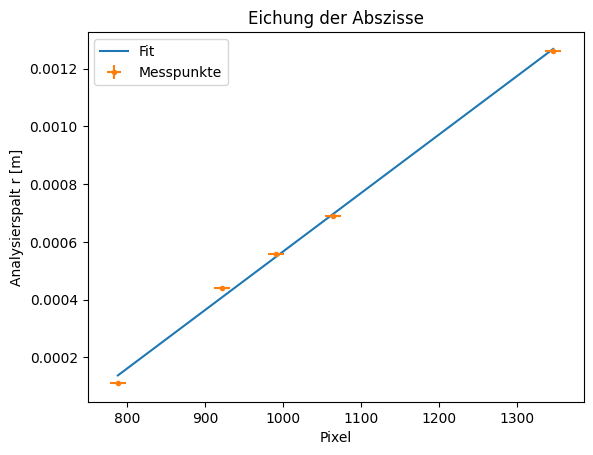

In [12]:
#Eichung der Abszisse 
#Fit (Wir ignorieren Fehler beim Ablesen der Pixel)
def linear(x,a,b):
    return a*x+b
popt, pcov = curve_fit(linear, cur, ana,sigma = ana_err, absolute_sigma = True)
scale = popt[0]
scale_err = np.sqrt(pcov[0,0])

#
#Plot
plt.plot(cur, linear(cur, *popt),label = "Fit")
plt.errorbar(cur,ana,xerr = cur_err,yerr = ana_err, linestyle='None', marker='.',label = "Messpunkte")
plt.xlabel('Pixel')
plt.ylabel('Analysierspalt r [m]')
plt.title('Eichung der Abszisse')
plt.legend()
print("Steigung:" ,popt[0],"\pm",scale_err, " m/pixel")
plt.savefig("Abszisseneichung.png")

In [13]:
#Bestimmung der Positionen der Minima und Maxima
#Position des 0. Maximums anhand der Daten mit dem 0. Maximum fast in Sättigung
peak0 = signal.find_peaks_cwt(intensity_0m,10,noise_perc = 50)
print(peak0)
peak0 = peak0[5:8]
print(peak0)
peak0_pix = pix_0m[peak0[:]]


[ 10  47  94 139 187 233 281 320 380 420 469 515 562 607 654 698]
[233 281 320]


In [14]:
#Bestimmung der Minima anhand der Daten mit dem 1. Maximum fast in Sättigung
valleys = signal.find_peaks_cwt(-intensity_1m,10)
valleys = valleys[0:14]
valleys_pix = pix_1m[valleys]

#Bestimmung des Abstands von Minima gleicher Ordnung
n_tot = int(len(valleys)/2)
n_min = np.arange(1,n_tot + 1)
dist_min = np.zeros(n_tot)
for i in n_min:
    dist_min[i-1] = valleys_pix[n_tot + i-1] - valleys_pix[n_tot-i]

#Für die Abstände nehmen wir einen Fehler von 10 Pixeln an
dist_min_err = 10

In [15]:
#Bestimmung der Maxima anhand der Daten mit dem 1. Maximum fast in Sättigung
peaks = signal.find_peaks_cwt(intensity_1m,np.arange(10,40),noise_perc=25,)
peaks = np.concatenate((peaks[1:8],peaks[10:17]))
peaks_pix = pix_1m[peaks]

#Bestimmung des Abstands der Maxima gleicher Ordnung
n_tot = int(len(peaks)/2)
n_max = np.arange(1,n_tot + 1)
dist_max = np.zeros(n_tot)
for i in n_max:
    dist_max[i-1] = peaks_pix[n_tot + i-1] - peaks_pix[n_tot-i]

#Für die Abstände nehmen wir einen Fehler von 10 Pixeln an
dist_max_err = 10

In [16]:
#Plot des Abstands der Minima und Maxima in Abhängigkeit ihrer Ordung

#Fit 
def linear(x,a,b):
    return a*x+b
popt, pcov = curve_fit(linear, n_min, dist_min,sigma = dist_min_err, absolute_sigma = True)
s = popt[0]
b = popt[1]
b_err = np.sqrt(pcov[1,1])
s_err = np.sqrt(pcov[0,0])

In [17]:
#Berechnung der zugehörigen Ordnungszahlen der Maxima

#Definition von Symbolen und Parametern
sa,sb, dmax= sp.symbols('a b d_max')
params = [sa,sb,dmax]
function = (dmax - sb)/sa

#Eingabe der Daten
werte = [s,s_err,b,b_err, dist_max,dist_max_err]
ph = uncertainty2(function,params,werte,params_without_error = [],latex = True)
n_max = ph[:,0]
n_max_err = ph[:,1]

Results:
[[0.32014831 0.14807948]
 [1.98578483 0.15651722]
 [3.00247216 0.1670067 ]
 [4.00834366 0.18058261]
 [5.01421505 0.19667991]
 [6.00927075 0.21452947]]
Funktion:


<IPython.core.display.Math object>

Latex Code:
\frac{1}{a} \left(- b + d_{max}\right)
Absoluter Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
\sqrt{\frac{1}{a^{4}} \left(a^{2} \left(\Delta b^{2} + \Delta d_{max}^{2}\right) + \Delta a^{2} \left(b - d_{max}\right)^{2}\right)}
Relativer Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
\sqrt{\frac{\Delta b^{2}}{\left(b - d_{max}\right)^{2}} + \frac{\Delta d_{max}^{2}}{\left(b - d_{max}\right)^{2}} + \frac{\Delta a^{2}}{a^{2}}}


Steigung: 92.40994520627508 pm 2.3904567439871256  pixel
y-Achsenabschnitt: 4.397762296091582 pm 9.309490718250487  pixel


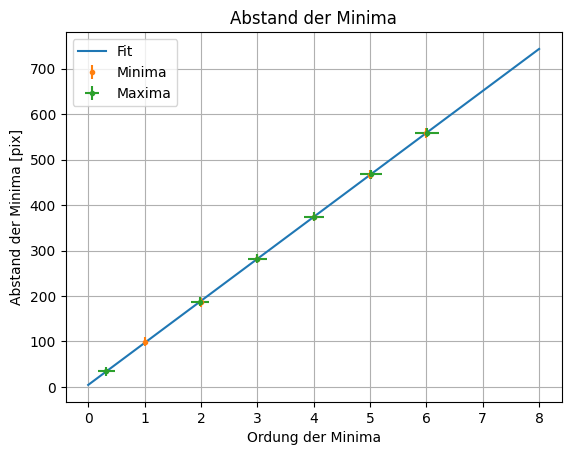

In [18]:
#Plot
x = np.linspace(0,8)
plt.plot(x, linear(x, *popt),label = "Fit")
plt.errorbar(n_min,dist_min,yerr = dist_min_err,linestyle='None', marker='.',label = "Minima")
plt.errorbar(n_max,dist_max, xerr = n_max_err, yerr = dist_max_err,linestyle='None', marker='.',label = "Maxima")

plt.xlabel('Ordung der Minima')
plt.ylabel('Abstand der Minima [pix]')
plt.title('Abstand der Minima')
plt.legend()
plt.grid()
print("Steigung:" ,s,"pm",s_err, " pixel")
print("y-Achsenabschnitt:" ,b,"pm",b_err, " pixel")

plt.savefig("Abstand-der-Minima.png")

In [19]:
#Bestimmung der Breite des Einzelspalts

#Definition von Symbolen und Parametern
f1, l, sc, ss= sp.symbols('f_1 \\lambda s_{mpp} s')
params = [f1,l,sc,ss]
function = 2*f1*l/(sc*ss)

#Eingabe der Daten
werte = [f_l1, lam,scale,scale_err,s,s_err]
ph = uncertainty2(function,params,werte,params_without_error = [f1,l])
b = ph[0][0]
b_err = ph[0][1]

Results:
[[4.55366884e-04 1.20860879e-05]]
Funktion:


<IPython.core.display.Math object>

Latex Code:
\frac{2 \lambda f_{1}}{s s_{mpp}}
Absoluter Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
2 \sqrt{\frac{1}{s^{4} s_{mpp}^{4}} \left(\lambda^{2} \Delta s^{2} f_{1}^{2} s_{mpp}^{2} + \lambda^{2} \Delta s_{mpp}^{2} f_{1}^{2} s^{2}\right)}
Relativer Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
\sqrt{\frac{\Delta s^{2}}{s^{2}} + \frac{\Delta s_{mpp}^{2}}{s_{mpp}^{2}}}


In [20]:
#Bestimmung der theoretischen Erwartung für die Lage der Maxima und ihrer Intensität
#Beugungsfunktion Spalt

#Beugungsbild des Einzelspalts (Parametrisiert durch die Ordnungszahl der Nebenmaxima)
def beugung_spalt(n):
    return np.sinc(n)**2

#Maxima dieser Funktion finden 
x = np.linspace(-8,8,10000)
y = beugung_spalt(x)
peaks_theo = signal.find_peaks_cwt(y, np.arange(0.1,0.15))
peaks_theo = peaks_theo[7:]
n_peaks_theo = x[peaks_theo]

In [23]:
#Vergleich mit den experimentellen Werten
# abw = Abweichung(n_peaks_theo,0,n_max,n_max_err)

In [25]:
#Erstellen der Tabelle für das Protokoll

# headr = np.array(['theoretische Ordnung', 'experimentelle Ordnung', 'Abweichung in $\sigma$'])
# captn = "Vergleich der theoretischen und experimentellen Ordungen der Maxima relativ zu den Minima"
# data = np.array([significant(0.05,daten = n_peaks_theo), to_latex(significant(n_max_err,n_max),significant(n_max_err)), significant(0.05, abw)])

# latex_tabelle(data,headr,captn)

In [26]:
#Berechnung der theoretisch erwarteten relativen Intensitäten der Maxima
I_rel_theo = beugung_spalt(n_peaks_theo)

In [27]:
I_rel_theo

array([0.04719031, 0.01648   , 0.00834026, 0.0050287 , 0.00336073,
       0.0024039 , 0.00180452])

In [28]:
#Bestimmung der relativen Intensitäten der gemessenen Maxima.

#Wir nehmen für den Fehler der Intensitäten 2% an. Dieser Fehler ergibt sich aus der imperfekten Bestimmung der Maxima durch Python.
#Um für die Asymetrie der gemessenen Vereitlung zu korrigieren, verwenden wir immer das arithmetische Mittel der Intensitäten beider Messungen zur selben Ordnung.
err_rel = 0.03
#Zuerst für die Intensitäten aus dem Bild mit dem 0. Maximum in fast maximaler Sättigung
I_0 = intensity_0m[peak0[1]]
I_0_err = I_0 * err_rel
I_11 = 1/2 * (intensity_0m[peak0[0]] + intensity_0m[peak0[2]])
I_11_err = err_rel * I_11

I_11_rel = I_11/I_0
I_11_rel_err = I_11_rel * np.sqrt(2)* err_rel

#Nun für die Intensitäten aus dem Bild mit dem 1. Max fast in Sättigung jeweils relativ zum 1. Maximum
I_abs = np.zeros(7)
I_abs_err = np.zeros(7)

#Mittelwertsbildung
for i in np.arange(1,8):
    I_abs[i-1] = 1/2*(intensity_1m[peaks[7 + i-1]] + intensity_1m[peaks[7 + i-1]])
    I_abs_err[i-1] = I_abs[i-1] * err_rel

I_rel1 = np.zeros(6)
I_rel1_err = np.zeros(6)

#Berechnung der Quotienten
for i in np.arange(0,6):
    I_rel1[i] = I_abs[i+1]/I_abs[0]
    print(i,"",I_rel1[i],"=",I_abs[i+1],"durch",I_abs[0])
    I_rel1_err[i] = I_rel1[i] *np.sqrt(2) * err_rel

I_rel = np.zeros(8)
I_rel[0] = 1
I_rel[1] = I_11_rel

I_rel_err = np.zeros(8)
I_rel_err[0] = 0
I_rel_err[1] = I_11_rel_err

#Finale Ergebnisse
for i in np.arange(1,7):
    I_rel[i+1] = I_rel1[i-1] * I_11_rel
    I_rel_err[i+1] = I_rel[i+1] * 2* err_rel

IndexError: index 13 is out of bounds for axis 0 with size 13

In [ ]:
#Abweichung von den theoretichen Werten
abw2 =Abweichung(I_rel[1:],I_rel_err[1:],I_rel_theo,0)

In [ ]:
#Tabelle für das Protokoll



data = np.array([significant(0.0005,daten =I_rel_theo), to_latex(I_rel[1:],I_rel_err[1:]), significant(0.05,daten = abw2)])
headr = np.array(['theoretische Intensität', 'gemessene Intensität', 'Abweichung in $\\sigma$'])
captn = 'Vergleich von den gemessenen relativen Intensitäten der Maxima mit der theoretischen Erwartung' 
latex_tabelle(data, headr, captn)

\begin{table}\label{}
	\centering
	\caption{Vergleich von den gemessenen relativen Intensitäten der Maxima mit der theoretischen Erwartung}
	\begin{tabular}{|c|c|c|}
 \hline		theoretische Intensität & gemessene Intensität & Abweichung in $\sigma$ \\ \hline
		0.0472 & $0.0437\pm 0.0019$ & 1.86 \\
		0.0165 & $0.0165\pm 0.001$ & 0.05 \\
		0.0083 & $0.0087\pm 0.0005$ & 0.71 \\
		0.005 & $0.0053\pm 0.0003$ & 0.98 \\
		0.0034 & $0.00384\pm 0.00023$ & 2.09 \\
		0.0024 & $0.00295\pm 0.00018$ & 3.07 \\
		0.0018 & $0.00248\pm 0.00015$ & 4.54 \\
\hline
	\end{tabular}
\end{table}


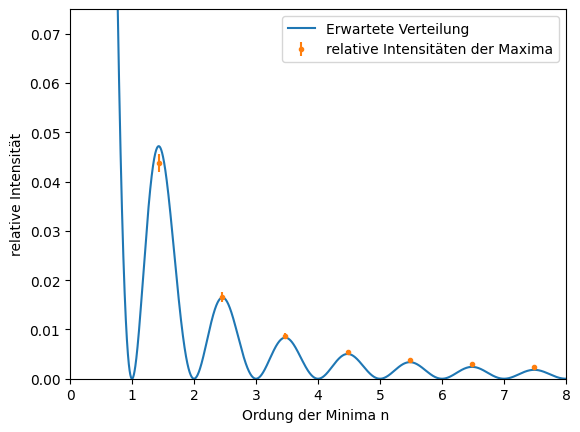

In [ ]:
#Plot
plt.plot(x,y,label="Erwartete Verteilung")
plt.errorbar(n_peaks_theo,I_rel[1:],yerr = I_rel_err[1:],fmt = ".", label = "relative Intensitäten der Maxima")
plt.ylim((0,0.075))
plt.xlim((0,8))
plt.xlabel("Ordung der Minima n ")
plt.ylabel("relative Intensität")
plt.legend()
plt.savefig("relative-Intensität.png")

# Aufgabe 3 Fouriersynthese des Einzelspalts

In [ ]:
#Einlesen der Daten und direkt normieren auf Maximum der 0.Ordnung

#Daten für 0. Max zugelassen
pix_0, intensity_0 = np.loadtxt('a40', unpack=True)
test = max(intensity_0)
max_int_0 = max(intensity_0) -min(intensity_0)
intensity_0 = intensity_0- np.min(intensity_0)
intensity_0 = intensity_0/max_int_0

#Daten für 0.,1. Max zugelassen
pix_1, intensity_1 = np.loadtxt('a41', unpack=True)
intensity_1 = intensity_1- np.min(intensity_1)
intensity_1 = intensity_1/max_int_0

#Daten für 0.,1.,2. Max zugelassen
pix_2, intensity_2 = np.loadtxt('a42', unpack=True)
intensity_2 = intensity_2- np.min(intensity_2)
intensity_2 = intensity_2/max_int_0

#Daten für 0.,1.,2.,3. Max zugelassen
pix_3, intensity_3 = np.loadtxt('a43', unpack=True)
intensity_3 = intensity_3- np.min(intensity_3)
intensity_3 = intensity_3/max_int_0

#Daten für 0.,1.,2.,3.,4. Max zugelassen
pix_4, intensity_4 = np.loadtxt('a44', unpack=True)
print(np.min(intensity_4)/test)
intensity_4 = intensity_4- np.min(intensity_4)
intensity_4 = intensity_4/max_int_0


#Daten für alle Max zugelassen
pix_alle, intensity_alle = np.loadtxt('Q4alle', unpack=True)
test2 = np.max(intensity_alle)
intensity_alle = intensity_alle- np.min(intensity_alle)
max_int_alle = max(intensity_alle)
intensity_alle = intensity_alle/max_int_0


0.025030212713804404


In [ ]:
#Einlesen der Daten

#Breite des Einzelspalts in Pixeln
b_pix = 76
b_pix_err = 3

#Bildweite in m
bild = 0.35
bild_err = 0.01

#Objektweite in m
obj = 0.117
obj_err = 0.003

#Breite eines Pixels der Kamera in m
mpp = 3.45/10**6


In [ ]:
#Bestimmung der Einzelspaltbreite mit f und b

#Definition von Symbolen und Parametern
b, B, f, umr = sp.symbols('b B_{pix} f_1, \\mu')
params = [b,B,f,umr]
function = f*B*umr/(b-f)

#Eingabe der Daten
werte = [bild,bild_err,b_pix,b_pix_err,f_l1,mpp]
uncertainty2(function,params,werte,params_without_error = [f,umr])

Results:
[[7.76888889e-05 4.20519691e-06]]
Funktion:


<IPython.core.display.Math object>

Latex Code:
\frac{B_{pix} \mu f_{1}}{b - f_{1}}
Absoluter Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
\sqrt{\frac{1}{\left(b - f_{1}\right)^{4}} \left(B_{pix}^{2} \mu^{2} \Delta b^{2} f_{1}^{2} + \mu^{2} \Delta B_{pix}^{2} f_{1}^{2} \left(b - f_{1}\right)^{2}\right)}
Relativer Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
\sqrt{\frac{\Delta b^{2}}{\left(b - f_{1}\right)^{2}} + \frac{\Delta B_{pix}^{2}}{B_{pix}^{2}}}


array([[7.76888889e-05, 4.20519691e-06]])

In [ ]:
#Bestimmung der Einzelspaltbreite mit f und g

#Definition von Symbolen und Parametern
g, B, f, umr = sp.symbols('g B f_1, \\mu')
params = [g,B,f,umr]
function = B*umr/f*(g - f)

#Eingabe der Daten
werte = [obj,obj_err,b_pix,b_pix_err,f_l1,mpp]
uncertainty2(function,params,werte,params_without_error = [f,umr])

Results:
[[1.21267500e-04 1.09358232e-05]]
Funktion:


<IPython.core.display.Math object>

Latex Code:
\frac{B \mu}{f_{1}} \left(- f_{1} + g\right)
Absoluter Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
\sqrt{\frac{1}{f_{1}^{2}} \left(B^{2} \mu^{2} \Delta g^{2} + \mu^{2} \Delta B^{2} \left(f_{1} - g\right)^{2}\right)}
Relativer Fehler:
Funktion:


<IPython.core.display.Math object>

Latex Code:
\sqrt{\frac{\Delta g^{2}}{\left(f_{1} - g\right)^{2}} + \frac{\Delta B^{2}}{B^{2}}}


array([[1.21267500e-04, 1.09358232e-05]])

In [ ]:
#Normierungsfaktors für die Vorhersage (Intensität des Maximums für 0. Ordnung zugelassen)
norm = np.float64(1.3897550841232986)

In [ ]:
#Theoretische Vorhersage für die Fouriersynthese
def synthese_einzelspalt(d,n):
    #Integrand
    def spalt(k,y):
        return d/np.pi*np.sin(k*d/2)/(k*d/2)*np.cos(y*k)
        
    
    #y-Werte:
    Y=np.linspace(-1,1,200)*d
    
    #Berechnung des resultierenden Objektbilds
    f_modifiziert=[]
    for i in range(len(Y)):
        y=Y[i]
        result, error = quad(spalt, 0, 2*np.pi*n/d, args =(y,))
        f_modifiziert.append(result**2)
    #Kurve auf 1 normieren:
    f_modifiziert = f_modifiziert/norm                     #np.max(f_modifiziert)
    return Y, f_modifiziert

0. Beugungsordung zugelassen

In [ ]:
#Finde Maximum 
peaks0 = signal.find_peaks_cwt(intensity_0,100)

In [ ]:
#Zentriere Verteilung
pix_0_z = pix_0 - peaks0[0]

In [ ]:
#Maxima der Vorhersage
peaks0_theo = signal.find_peaks(synthese_einzelspalt(b_pix,1)[1])[0]

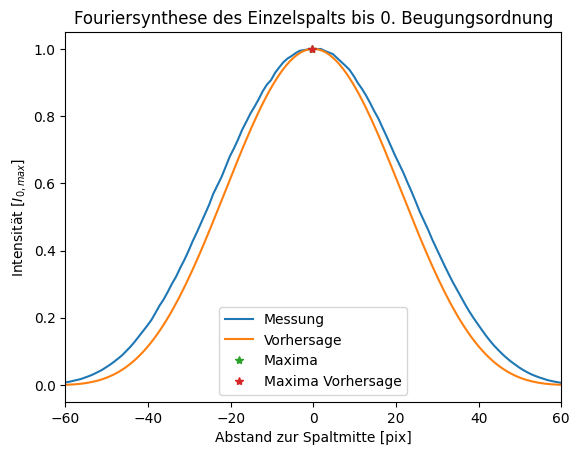

In [ ]:
plt.plot(pix_0_z,intensity_0,label = "Messung")
plt.xlim((-60,60))
plt.plot(synthese_einzelspalt(b_pix,1)[0],synthese_einzelspalt(b_pix,1)[1], label = "Vorhersage")
plt.plot(pix_0_z[peaks0],intensity_0[peaks0],marker = "*",label = "Maxima",linewidth = 0)
plt.plot(synthese_einzelspalt(b_pix,1)[0][peaks0_theo[0]],synthese_einzelspalt(b_pix,1)[1][peaks0_theo[0]],marker = "*",label = "Maxima Vorhersage",linewidth = 0)
plt.title("Fouriersynthese des Einzelspalts bis 0. Beugungsordnung")
plt.legend()
plt.xlabel('Abstand zur Spaltmitte [pix]')
plt.ylabel('Intensität [$I_{0,max}$]')
plt.savefig("A40.png")

In [ ]:
#Relative Intensitäten der Peaks Messung
print(intensity_0[peaks0])

#Relative Intensitäten der Peaks theoretisch
print(synthese_einzelspalt(b_pix,1)[1][peaks0_theo[0]])
print(Abweichung_proz(synthese_einzelspalt(b_pix,1)[1][peaks0_theo[0]],intensity_0[peaks0]))

[0.99982326]
1.0
[0.01767409]


1. Beugungsordnung zugelassen

In [ ]:
#Finde Maxima 
peaks1 = signal.find_peaks_cwt(intensity_1,15,noise_perc = 30)
peaks1 = peaks1[2:4]

#Finde Minima 
valleys1 = signal.find_peaks_cwt(intensity_1,100,noise_perc = 20)

In [ ]:
#Zentriere Verteilung
pix_1_z = pix_1 - valleys1[0]

In [ ]:
#Maxima der Vorhersage
peaks1_theo = signal.find_peaks(synthese_einzelspalt(b_pix,2)[1],height = 0.5)[0]

#Minima der Vorhersage
valleys1_theo = signal.find_peaks(-synthese_einzelspalt(b_pix,2)[1],height = -1)[0]
valleys1_theo = valleys1_theo[2]

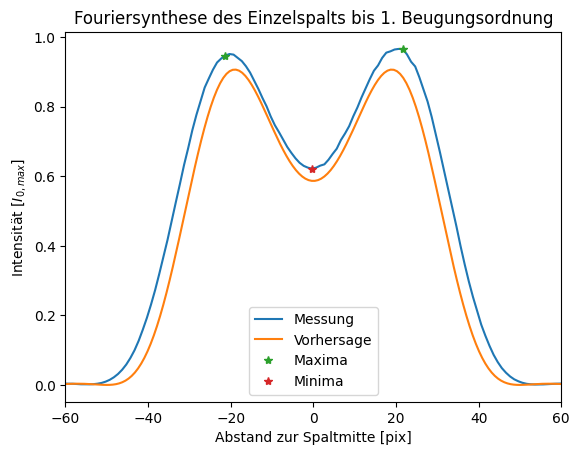

In [ ]:

plt.plot(pix_1_z,intensity_1,label = "Messung")
plt.plot(synthese_einzelspalt(b_pix,2)[0],synthese_einzelspalt(b_pix,2)[1], label = "Vorhersage")
plt.plot(pix_1_z[peaks1],intensity_1[peaks1],marker = "*",label = "Maxima",linewidth = 0)
#plt.plot(synthese_einzelspalt(b_pix,2)[0][peaks1_theo],synthese_einzelspalt(b_pix,2)[1][peaks1_theo],marker = "*",label = "Maxima Vorhersage",linewidth = 0)
#plt.plot(synthese_einzelspalt(b_pix,2)[0][valleys1_theo],synthese_einzelspalt(b_pix,2)[1][valleys1_theo],marker = "*",label = "Maxima Vorhersage",linewidth = 0)
plt.plot(pix_1_z[valleys1],intensity_1[valleys1],marker = "*",label = "Minima",linewidth = 0)
plt.xlim((-60,60))
plt.title("Fouriersynthese des Einzelspalts bis 1. Beugungsordnung")
plt.legend()
plt.xlabel('Abstand zur Spaltmitte [pix]')
plt.ylabel('Intensität [$I_{0,max}$]')
plt.savefig("A41.png")

In [ ]:
#Relative Intensitäten der Peaks Messung
print("Peaks Messung:",intensity_1[peaks1])

#Relative Intensität der Valleys Messung
print("Valleys Messung:",intensity_1[valleys1])


#Relative Intensitäten der Peaks theoretisch
print("Peaks theo:",synthese_einzelspalt(b_pix,2)[1][peaks1_theo])

#Relative Intensitäten der Valleys theoretisch
print("Valleys theo:",synthese_einzelspalt(b_pix,2)[1][valleys1_theo])

#Prozentuale Abweichung
print("Prozentuale Abweichung Peaks:", Abweichung_proz(synthese_einzelspalt(b_pix,2)[1][peaks1_theo],intensity_1[peaks1]))
print("Prozentuale Abweichung Valleys:", Abweichung_proz(synthese_einzelspalt(b_pix,2)[1][valleys1_theo],intensity_1[valleys1]))

Peaks Messung: [0.94696673 0.96518822]
Valleys Messung: [0.62192592]
Peaks theo: [0.90653024 0.90653024]
Valleys theo: 0.5867614278742624
Prozentuale Abweichung Peaks: [4.4605782  6.47060366]
Prozentuale Abweichung Valleys: [5.99297992]


2. Beugungsordnung zugelassen

In [ ]:
#Finde Maxima 
peaks2 = signal.find_peaks(intensity_2,threshold = 0.0005)[0]

#Finde Minima 
valleys2 = signal.find_peaks(-intensity_2,threshold = 0.001)[0]

In [ ]:
#Zentriere Verteilung
pix_2_z = pix_2 - peaks2[1]

In [ ]:
#Maxima der Vorhersage
peaks2_theo = signal.find_peaks(synthese_einzelspalt(b_pix,3)[1],height = 0.5)[0]

#Minima der Vorhersage
valleys2_theo = signal.find_peaks(-synthese_einzelspalt(b_pix,3)[1],height = -1)[0]
valleys2_theo = valleys2_theo[3:5]

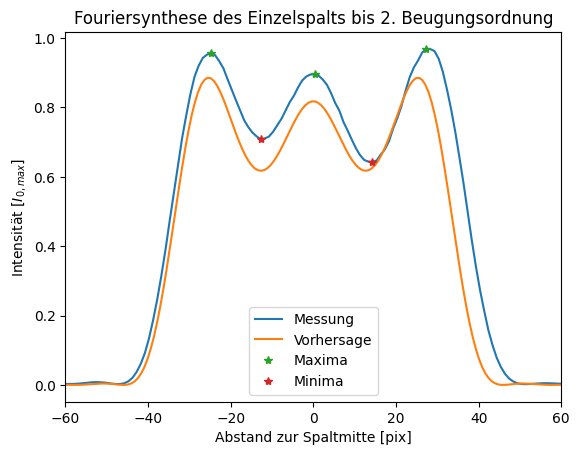

In [ ]:

plt.plot(pix_2_z,intensity_2,label = "Messung")
plt.plot(synthese_einzelspalt(b_pix,3)[0],synthese_einzelspalt(b_pix,3)[1], label = "Vorhersage")
plt.plot(pix_2_z[peaks2],intensity_2[peaks2],marker = "*",label = "Maxima",linewidth = 0)
plt.plot(pix_2_z[valleys2],intensity_2[valleys2],marker = "*",label = "Minima",linewidth = 0)
#plt.plot(synthese_einzelspalt(b_pix,3)[0][peaks2_theo],synthese_einzelspalt(b_pix,3)[1][peaks2_theo],marker = "*",label = "Maxima Vorhersage",linewidth = 0)
#plt.plot(synthese_einzelspalt(b_pix,3)[0][valleys2_theo],synthese_einzelspalt(b_pix,3)[1][valleys2_theo],marker = "*",label = "Maxima Vorhersage",linewidth = 0)
plt.xlim((-60,60))
plt.title("Fouriersynthese des Einzelspalts bis 2. Beugungsordnung")
plt.legend()
plt.xlabel('Abstand zur Spaltmitte [pix]')
plt.ylabel('Intensität [$I_{0,max}$]')
plt.savefig("A42.png")

In [ ]:
#Relative Intensitäten der Peaks Messung
print("Peaks Messung:",intensity_2[peaks2])

#Relative Intensität der Valleys Messung
print("Valleys Messung:",intensity_2[valleys2])


#Relative Intensitäten der Peaks theoretisch
print("Peaks theo:",synthese_einzelspalt(b_pix,3)[1][peaks2_theo])

#Relative Intensitäten der Valleys theoretisch
print("Valleys theo:",synthese_einzelspalt(b_pix,3)[1][valleys2_theo])

#Prozentuale Abweichung
print("Prozentuale Abweichung Peaks:", Abweichung_proz(synthese_einzelspalt(b_pix,3)[1][peaks2_theo],intensity_2[peaks2]))
print("Prozentuale Abweichung Valleys:", Abweichung_proz(synthese_einzelspalt(b_pix,3)[1][valleys2_theo],intensity_2[valleys2]))

Peaks Messung: [0.95747396 0.89582288 0.96888294]
Valleys Messung: [0.70823561 0.6427735 ]
Peaks theo: [0.88552437 0.81748791 0.88552437]
Valleys theo: [0.61751881 0.61751881]
Prozentuale Abweichung Peaks: [8.12508303 9.5824004  9.41347025]
Prozentuale Abweichung Valleys: [14.69053082  4.08970283]


3. Beugungsordnung zugelassen

In [ ]:
#Finde Maxima 
peaks3 = signal.find_peaks(intensity_3,threshold = 0.001)[0]

#Finde Minima 
valleys3 = signal.find_peaks(-intensity_3,threshold = 0.001)[0]

In [ ]:
#Zentriere Verteilung
pix_3_z = pix_3 - valleys3[1]

In [ ]:
#Maxima der Vorhersage
peaks3_theo = signal.find_peaks(synthese_einzelspalt(b_pix,4)[1],height = 0.5)[0]

#Minima der Vorhersage
valleys3_theo = signal.find_peaks(-synthese_einzelspalt(b_pix,4)[1],height = -1)[0]
valleys3_theo = valleys3_theo[4:7]

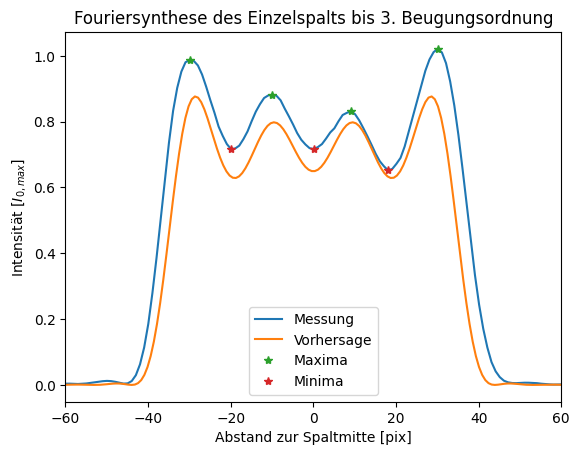

In [ ]:
plt.plot(pix_3_z,intensity_3,label = "Messung")
plt.plot(synthese_einzelspalt(b_pix,4)[0],synthese_einzelspalt(b_pix,4)[1], label = "Vorhersage")
plt.plot(pix_3_z[peaks3],intensity_3[peaks3],marker = "*",label = "Maxima",linewidth = 0)
plt.plot(pix_3_z[valleys3],intensity_3[valleys3],marker = "*",label = "Minima",linewidth = 0)
#plt.plot(synthese_einzelspalt(b_pix,4)[0][peaks3_theo],synthese_einzelspalt(b_pix,4)[1][peaks3_theo],marker = "*",label = "Maxima Vorhersage",linewidth = 0)
#plt.plot(synthese_einzelspalt(b_pix,4)[0][valleys3_theo],synthese_einzelspalt(b_pix,4)[1][valleys3_theo],marker = "*",label = "Maxima Vorhersage",linewidth = 0)
plt.xlim((-60,60))
plt.title("Fouriersynthese des Einzelspalts bis 3. Beugungsordnung")
plt.legend()
plt.xlabel('Abstand zur Spaltmitte [pix]')
plt.ylabel('Intensität [$I_{0,max}$]')
plt.savefig("A43.png")

In [ ]:
#Relative Intensitäten der Peaks Messung
print("Peaks Messung:",intensity_3[peaks3])

#Relative Intensität der Valleys Messung
print("Valleys Messung:",intensity_3[valleys3])


#Relative Intensitäten der Peaks theoretisch
print("Peaks theo:",synthese_einzelspalt(b_pix,4)[1][peaks3_theo])

#Relative Intensitäten der Valleys theoretisch
print("Valleys theo:",synthese_einzelspalt(b_pix,4)[1][valleys3_theo])

#Prozentuale Abweichung
print("Prozentuale Abweichung Peaks:", Abweichung_proz(synthese_einzelspalt(b_pix,4)[1][peaks3_theo],intensity_3[peaks3]))
print("Prozentuale Abweichung Valleys:", Abweichung_proz(synthese_einzelspalt(b_pix,4)[1][valleys3_theo],intensity_3[valleys3]))

Peaks Messung: [0.98734841 0.88180078 0.83167887 1.02112155]
Valleys Messung: [0.71680529 0.71680165 0.65189199]
Peaks theo: [0.87664297 0.7981384  0.7981384  0.87664297]
Valleys theo: [0.62893892 0.64986381 0.62893892]
Prozentuale Abweichung Peaks: [12.62833835 10.48218943  4.2023379  16.48089264]
Prozentuale Abweichung Valleys: [13.9705728  10.30028642  3.6494901 ]


4. Beugungsordnung zugelassen

In [ ]:
#Finde Maxima 
peaks4 = signal.find_peaks(intensity_4,threshold = 0.0005)[0]
peaks4 = peaks4[1:]

#Finde Minima 
valleys4 = signal.find_peaks(-intensity_4,threshold = 0.001)[0]

In [ ]:
#Zentriere Verteilung
pix_4_z = pix_4 - peaks4[2]

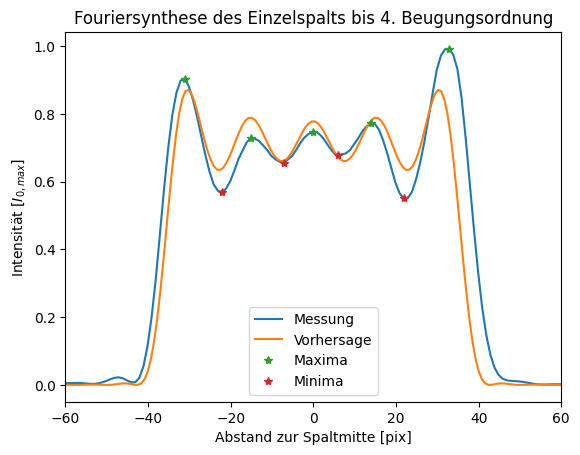

In [ ]:
plt.plot(pix_4_z,intensity_4,label = "Messung")
plt.plot(synthese_einzelspalt(b_pix,5)[0],synthese_einzelspalt(b_pix,5)[1], label = "Vorhersage")
plt.plot(pix_4_z[peaks4],intensity_4[peaks4],marker = "*",label = "Maxima",linewidth = 0)
plt.plot(pix_4_z[valleys4],intensity_4[valleys4],marker = "*",label = "Minima",linewidth = 0)
plt.xlim((-60,60))
plt.title("Fouriersynthese des Einzelspalts bis 4. Beugungsordnung")
plt.legend()
plt.xlabel('Abstand zur Spaltmitte [pix]')
plt.ylabel('Intensität [$I_{0,max}$]')
plt.savefig("A44.png")

alle Beugungsordnungen zugelassen

In [ ]:
#Finde Maxima 
#peaksalle = signal.find_peaks(intensity_alle,threshold = 0.01)[0]

#Finde Minima 
valleysalle = signal.find_peaks(-intensity_alle,threshold = 0.01,height = -0.8)[0]

In [ ]:
#Zentriere Verteilung (diesmal händisch)
pix_alle_z = pix_alle - valleysalle[2]-5

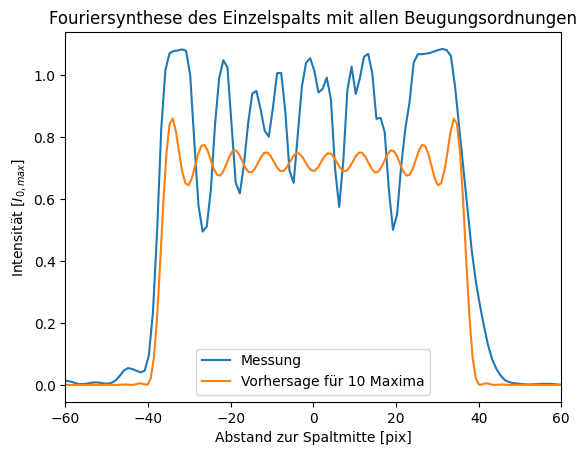

In [ ]:
plt.plot(pix_alle_z,intensity_alle,label = "Messung")
plt.plot(synthese_einzelspalt(b_pix,10)[0],synthese_einzelspalt(b_pix,10)[1], label = "Vorhersage für 10 Maxima")
#plt.plot(pix_4_z[peaks4],intensity_4[peaks4],marker = "*",label = "Maxima",linewidth = 0)
#plt.plot(pix_alle_z[valleysalle],intensity_alle[valleysalle],marker = "*",label = "Minima",linewidth = 0)
plt.xlim((-60,60))
plt.title("Fouriersynthese des Einzelspalts mit allen Beugungsordnungen")
plt.legend()
plt.xlabel('Abstand zur Spaltmitte [pix]')
plt.ylabel('Intensität [$I_{0,max}$]')
plt.savefig("A4alle.png")

# Aufgabe 2 Beugungsbild des Doppelspalts

In [ ]:
# Einlesen der Messwerte

fehler_diff = 5 #Pixel

#Beite der Einzelspalte in Pixeln
bd1 = 247
bd2 = 255
#Mittelwert 
bd_pix = (bd1+bd2)/2
bd_pix_err = fehler_diff/np.sqrt(2)

#Abstand der Spalte in Pixeln
gd_pix = 586
gd_pix_err = fehler_diff

#Objektweite g in m
obj2 = 0.1 
obj2_err = 0.005

#Bildweite in m 
bild2 = 0.355
bild2_err = 0.005

#Position der Minima und Maxima in Pixeln zentriert
pix_d_ext = np.array([221,232,257,274,295,316,334,356,369])
offset = pix_d_ext[4]
pix_d_ext = pix_d_ext - offset
pix_d_ext_err = 3

#Intensitätsprofil einlesen, zentrieren und normieren
pix_d, intensity_d = np.loadtxt('a32', unpack=True)
pix_d = pix_d - offset
maxint = np.max(intensity_d)
intensity_d = intensity_d/ maxint

#Intensität der Minima und Maxima normiert auf das 0. Maximum der vollständigen Daten
intensity_d_ext = np.array([31,8,425,15,814,20,455,7,39])
intensity_d_ext_err = 3/ maxint
intensity_d_ext = intensity_d_ext/ maxint

In [ ]:
print(bd_pix)
print(bd_pix_err)

251.0
3.5355339059327373


In [ ]:
#Bestimmung der Einzelspaltbreite mit f und b

#Definition von Symbolen und Parametern
b, B, f, umr = sp.symbols('b B f_1, \\mu')
params = [b,B,f,umr]
function = f*B*umr/(b-f)

#Eingabe der Daten
werte = [bild2,bild2_err,bd_pix,bd_pix_err,f_l1,mpp]
ph = uncertainty2(function,params,werte,params_without_error = [f,umr],latex = False)
bd = ph[0][0]
bd_err = ph[0][1]

Results:
[[2.51912727e-04 5.79392735e-06]]


In [ ]:
#Bestimmung des Spaltabstands mit f und b

#Definition von Symbolen und Parametern
b, B, f, umr = sp.symbols('b B f_1, \\mu')
params = [b,B,f,umr]
function = f*B*umr/(b-f)

#Eingabe der Daten
werte = [bild2,bild2_err,gd_pix,gd_pix_err,f_l1,mpp]
ph = uncertainty2(function,params,werte,params_without_error = [f,umr],latex = False)
gd = ph[0][0]
gd_err = ph[0][1]

Results:
[[5.88130909e-04 1.18122218e-05]]


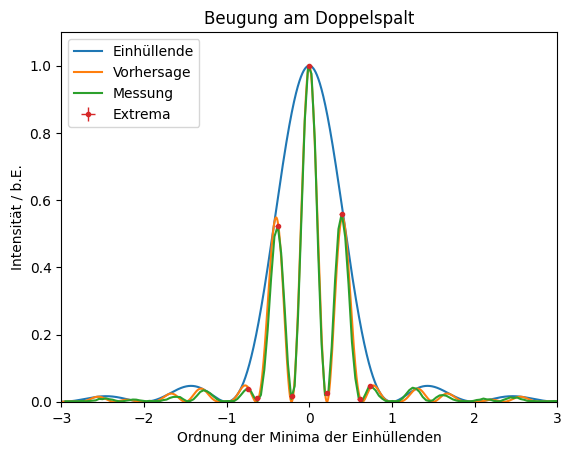

In [ ]:
#Theoretische Vorhersage für das Beugungsbild des Doppelspalts
#Beugungsfunktion Doppelspalt
def beugung_doppelspalt(x):
    return np.sinc(x)**2*np.cos(np.pi*v*x)**2

#Anzahl a der Nebenmaxima die dargestellt werden sollen:
a=2
#Verhaeltnis Spaltabstand zu Spaltbreite:
v=gd/bd
x=np.linspace(-(a+1),a+1,2000)
plt.plot(x,beugung_spalt(x),label='Einhüllende')
plt.plot(x,beugung_doppelspalt(x),label='Vorhersage')
plt.plot(pix_d/100,intensity_d, label = "Messung")
plt.errorbar(pix_d_ext/100,intensity_d_ext,yerr = intensity_d_ext_err,xerr = pix_d_ext_err/100,fmt = ".",linewidth = 1, label = "Extrema")

plt.xlabel('Ordnung der Minima der Einhüllenden')
plt.ylabel('Intensität / b.E.')
plt.title('Beugung am Doppelspalt')
plt.ylim((0,1.1))
plt.legend(loc = "upper left")
plt.xlim((-3,3))
plt.savefig("Doppelspalt.png")
#plt.savefig("figures/Beugung_spalt_doppelspalt.pdf", format="pdf")

In [ ]:
#Bestimmung der theoretischen Extrema
peaksd_theo = signal.find_peaks(beugung_doppelspalt(x),height = 0.04)[0]
valleysd_theo = signal.find_peaks(-beugung_doppelspalt(x),height = -1,threshold = 0.00001)[0]
valleysd_theo = valleysd_theo[1:5]
extd_theo = np.concatenate((peaksd_theo,valleysd_theo))
extd_theo = np.sort(extd_theo)

In [ ]:
#Bestimmung der experimentellen Extrema
peaksd = signal.find_peaks(intensity_d,height = 0.04)[0]
peaksd = peaksd[0:5]
valleysd = signal.find_peaks(-intensity_d,height = -1,threshold = 0.005)[0]
extd = np.concatenate((peaksd,valleysd))
extd = np.sort(extd)

In [ ]:
#Intensitäten der theoretischen Extrema
print(beugung_doppelspalt(x)[extd_theo])

[4.85390325e-02 1.88383188e-05 5.48449127e-01 9.07121607e-06
 9.99871435e-01 9.07121607e-06 5.48449127e-01 1.88383188e-05
 4.85390325e-02]


In [ ]:
#Intensitäten der gemessenen Extrema (Bestimmung mit Python)
print(intensity_d[extd])

[0.0402678  0.0022581  0.52332414 0.00839485 1.         0.02010455
 0.56128146 0.00250341 0.04443189]


In [ ]:
#Intensitäten der gemessenen Extrema (Bestimmung mit Cursor)
print(intensity_d_ext)

[0.03805531 0.00982073 0.52172606 0.01841386 0.99925885 0.02455181
 0.55855378 0.00859314 0.04787604]


In [ ]:
#Abweichung der Cursor Werte mit der Theorie
Abweichung(intensity_d_ext,intensity_d_ext_err,beugung_doppelspalt(x)[extd_theo],0)

array([2.84669248, 2.66155141, 7.2562368 , 4.99753685, 0.16633676,
       6.66420352, 2.7437632 , 2.32821808, 0.18002581])

In [ ]:
#Abweichung der Python Werte mit der Theorie
Abweichung(intensity_d[extd],intensity_d_ext_err,beugung_doppelspalt(x)[extd_theo],0)

array([2.24592681, 0.60803805, 6.82230347, 2.27703022, 0.03490991,
       5.45661618, 3.4844232 , 0.67464618, 1.11523015])

In [ ]:
#Tabelle für das Protokoll

extrema = np.array(["-2.Max","-2.Min","-1.Max","-1.Min","0.Max","1.Min","1.Max","2.Min","2.Max"])
data = np.array([extrema, significant(0.005,daten =beugung_doppelspalt(x)[extd_theo]), to_latex(intensity_d_ext,intensity_d_ext_err), significant(0.05,daten = Abweichung(intensity_d_ext,intensity_d_ext_err,beugung_doppelspalt(x)[extd_theo],0)), to_latex(intensity_d[extd],intensity_d_ext_err),significant(0.05,daten = Abweichung(intensity_d[extd],intensity_d_ext_err,beugung_doppelspalt(x)[extd_theo],0))])
headr = np.array(["Extremum",'Theorie', 'Cursor', 'Abweichung Curser in $\\sigma$',"Python", 'Abweichung Python in $\\sigma$'])
captn = 'Vergleich von den gemessenen relativen Intensitäten der Extrema unter dem 0. Maximum der Einhüllenden mit der theoretischen Erwartung. Dabei bezeichnet ''Cursor'' die Intensitäten der händisch bestimmten Extrema und ''Python'' die der mit Python bestimmten. Das Vorzeichen der Ordnung der Extrema kennzeichnet sie Seite des Extrems. ' 
latex_tabelle(data, headr, captn)

\begin{table}\label{}
	\centering
	\caption{Vergleich von den gemessenen relativen Intensitäten der Extrema unter dem 0. Maximum der Einhüllenden mit der theoretischen Erwartung. Dabei bezeichnet Cursor die Intensitäten der händisch bestimmten Extrema und Python die der mit Python bestimmten. Das Vorzeichen der Ordnung der Extrema kennzeichnet sie Seite des Extrems. }
	\begin{tabular}{|c|c|c|c|c|c|}
 \hline		Extremum & Theorie & Cursor & Abweichung Curser in $\sigma$ & Python & Abweichung Python in $\sigma$ \\ \hline
		-2.Max & 0.049 & $0.038\pm 0.004$ & 2.85 & $0.04\pm 0.004$ & 2.25 \\
		-2.Min & 0.0 & $0.01\pm 0.004$ & 2.66 & $0.002\pm 0.004$ & 0.61 \\
		-1.Max & 0.548 & $0.522\pm 0.004$ & 7.26 & $0.523\pm 0.004$ & 6.82 \\
		-1.Min & 0.0 & $0.018\pm 0.004$ & 5.0 & $0.008\pm 0.004$ & 2.28 \\
		0.Max & 1.0 & $0.999\pm 0.004$ & 0.17 & $1.0\pm 0.004$ & 0.04 \\
		1.Min & 0.0 & $0.025\pm 0.004$ & 6.66 & $0.02\pm 0.004$ & 5.46 \\
		1.Max & 0.548 & $0.559\pm 0.004$ & 2.74 & $0.561\pm 0.004$ 

# Aufgabe 4 Fouriersynthese des Doppelspalts

In [ ]:
#Einlesen der Daten
pix_da, intensity_da = np.loadtxt('a5posa_Intensitätsverteilung', unpack=True)

pix_db, intensity_db = np.loadtxt('a5posb_Intensitätsverteilung', unpack=True)

#halbe Breite des Analysierspalts am kritischen Punkt (Situation b) in m
ana_crit = 0.000040
ana_crit_err = 0.000005

#halbe Breite des Analysierspalts in Situation a
anaa = 0.00019
anaa_err = 0.000005

In [ ]:
#Zentrieren der Abb a
#Finden der Maxima
peaksa = signal.find_peaks(intensity_da, height = 500)[0]
offset = (pix_da[peaksa[0]] + pix_da[peaksa[1]])/2

pix_da = pix_da - offset

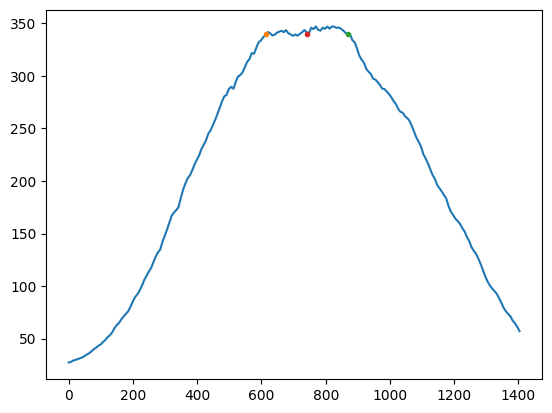

In [ ]:
#Zentrieren der Abb b
plt.plot(pix_db, intensity_db)
plt.plot(615,340,marker = ".")
plt.plot(870,340,marker = ".")
plt.plot(742.5,340,marker= ".")

pix_db = pix_db - 742.5

In [ ]:
#Theoretische Vorhersage für die Fouriersynthese
def synthese_doppelspalt(g,d,n):
    #Integrand
    def doppelspalt(k):
        return d/np.pi*np.cos(k*g/2)*np.sin(k*d/2)/(k*d/2)*np.cos(y*k)
        
    
    #y-Werte:
    Y=np.linspace(-1,1,2000)*(g+10)
    
    #Berechnung des resultierenden Objektbilds
    f_modifiziert=[]
    for i in range(len(Y)):
        y=Y[i]
        result, error = quad(doppelspalt, 0, 2*np.pi*n/d)
        f_modifiziert.append(result**2)
    
    #Kurve auf 1 normieren:
    f_modifiziert = f_modifiziert/np.max(f_modifiziert)
    return Y, f_modifiziert

In [ ]:
#Stauchen der Abb
peaksa_theo = signal.find_peaks(synthese_doppelspalt(gd/mpp,bd/mpp,1)[1],height = 0.3)[0]
stauch = (synthese_doppelspalt(gd/mpp,bd/mpp,1)[0][peaksa_theo[1]] - synthese_doppelspalt(gd/mpp,bd/mpp,1)[0][peaksa_theo[0]])/(pix_da[peaksa[1]]-pix_da[peaksa[0]])

In [ ]:
#Normieren der Intensität
norma = (intensity_da[peaksa[0]] + intensity_da[peaksa[1]])/2
#norm_theo = np.float64(0.34945771903187856)

In [ ]:
#Normieren der Messdaten
intensity_da = intensity_da/norma
intensity_db = intensity_db/np.max(intensity_db)

In [ ]:
#Theoretische Vorhersage für a)
a_theo_x = synthese_doppelspalt(gd/mpp,bd/mpp,1)[0] 
a_theo_x = a_theo_x / stauch
a_theo_y = synthese_doppelspalt(gd/mpp,bd/mpp,1)[1]
#a_theo_y = a_theo_y/norm_theo

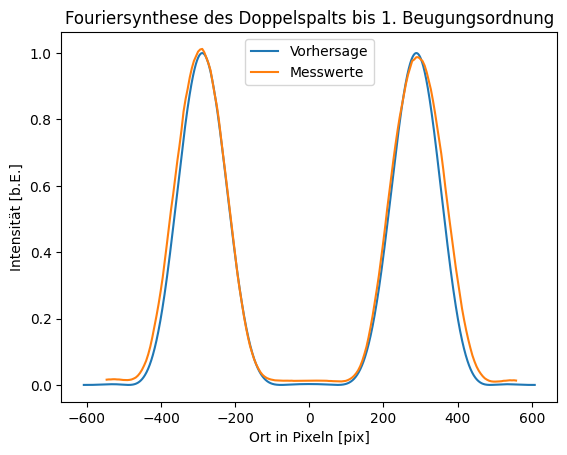

In [ ]:
plt.plot(a_theo_x,a_theo_y,label = "Vorhersage")
plt.plot(pix_da,intensity_da,label = "Messwerte")
plt.title("Fouriersynthese des Doppelspalts bis 1. Beugungsordnung")
plt.legend()
plt.xlabel('Ort in Pixeln [pix]')
plt.ylabel('Intensität [b.E.]')
plt.savefig("A5a.png")

In [ ]:
#Berechnung des kritischen ky
ka2 = 2*np.pi/bd
#Berechnung des kritischen ky aus der Messung 
ka = 2*np.pi/(lam*f_l1)*anaa
ka_err = 2*np.pi/(lam*f_l1)*anaa_err

In [ ]:
print(ka)
print(ka_err)

28049.934407051725
738.1561686066244


In [ ]:
print(ka2)

24941.912920410905


In [ ]:
Abweichung(ka,ka_err,ka2,0)

4.210520237889032

In [ ]:
#Theoretische Vorhersage für a)
var = 0.268   #Mit dieser Variable kann graphisch die optimale Beugungsordnung bestimmt werden
b_theo_x = synthese_doppelspalt(gd/mpp,bd/mpp,var)[0] 
b_theo_x = b_theo_x / stauch
b_theo_y = synthese_doppelspalt(gd/mpp,bd/mpp,var)[1]
#b_theo_y = b_theo_y/norm_theo

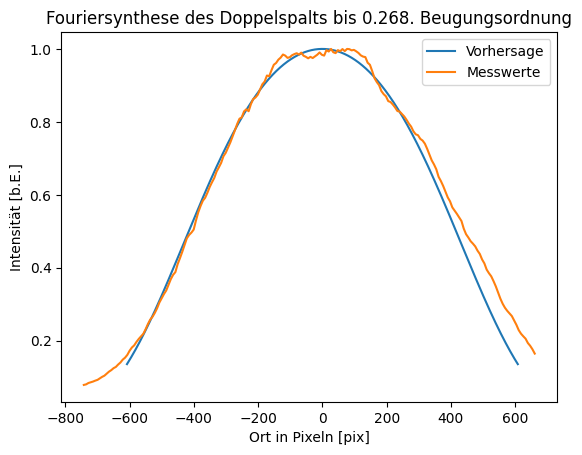

In [ ]:
plt.plot(b_theo_x,b_theo_y,label = "Vorhersage")
plt.plot(pix_db,intensity_db,label = "Messwerte")
plt.title("Fouriersynthese des Doppelspalts bis "+str(round(var,3))+". Beugungsordnung")
plt.legend()
plt.xlabel('Ort in Pixeln [pix]')
plt.ylabel('Intensität [b.E.]')
plt.savefig("A5b.png")

In [ ]:
#Berechnung des kritischen ky
var_opt = 0.286
var_opt_err = 0.003
k_crit2 = 2*np.pi*var_opt/bd
k_crit2_err = 2*np.pi/bd**var_opt_err

In [ ]:
#Berechnung des kritischen ky aus der Messung 
k_crit = 2*np.pi/(lam*f_l1)*ana_crit
k_crit_err = 2*np.pi/(lam*f_l1)*ana_crit_err


In [ ]:
print(k_crit)
print(k_crit_err)

5905.249348852995
738.1561686066244


In [ ]:
print(k_crit2)
print(k_crit2_err)

7133.387095237519
6.441338434469675


In [ ]:
Abweichung(k_crit,k_crit_err, k_crit2,k_crit2_err)

1.6637278687990047